# Symptom prevalence and covid status tables

## Import libraries 

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from numpy import cos, pi, sqrt, nan, logical_and

### Set working dir_ 

In [2]:
os.chdir('S:\LLC_0028\data')

In [3]:
if 'symptom_analysis' not in os.listdir():
    os.mkdir('symptom_analysis')
    
#os.chdir('symptom_analysis')

## Import data 

In [4]:
dta = pd.read_csv('./harmonised_all/llc_0028_full_harmonised_data_all_v2.csv', index_col=0)

In [6]:
core_symp = ['fever','cough','throat',
            'chest_tight','breath','nose','aches',
             'fatigue', 'diarrhoea','smell_taste',
            'nausea_vomit', 'sneezing',
             'headache','concentrating','memory']

In [7]:
dta = dta.dropna(how='any',subset=core_symp)

In [8]:
dta.shape

(26144, 43)

In [9]:
dta = dta[core_symp + ['study','covid_status']] #only need symptoms, study and status

## Prevalence table 

In [10]:
os.chdir('symptom_analysis')

In [11]:
prevalence = pd.DataFrame(index = ['sample size'] + core_symp)

In [13]:
dta2 = dta

In [15]:
symptoms = core_symp
prevalence['Pooled_N'] = [dta2.shape[0]] + [ v for v in dta2[symptoms].sum().values]
prevalence['Pooled_%'] = [''] + [ round(v,2) for v in dta2.describe().T['mean'].values[:-1]*100]

for study,group in dta2.groupby('study'):
    
    df = group.describe().T
    #add a catch so that if prevalence * sample size < 10, fill with 
    #-*. When v==0, it is because a study didnt ask about that symptom
    #therefore this is left as 0.00 (not starred) unless sample size < 10
    if df['count'].values[0]<=10:
        ssize = '<10'
        prevalence[study+'_N'] = [ssize] + [0.0 for v in group[symptoms].sum().values]   
        prevalence[study+'_%'] = [''] + ['-*' for v in group[symptoms].sum().values]
        
    else:
        ssize = df['count'].values[0]
        prevalence[study+'_N'] = [ssize] + [v if v>10 or v==0 else 0.0 for v in group[symptoms].sum().values]   
        prevalence[study+'_%'] = [''] + \
                        [round(v,2) if v*df['count'].values[0]/100 >=10 \
                         else '-*' for v in df['mean'].values[:-1]*100]

In [16]:
prevalence.to_csv('llc_0028_symptom_prevalence_core_data_v1.csv')

### Prevalence by covid category 

#### No covid 

In [17]:
prevalence = pd.DataFrame(index = ['sample size'] + list(symptoms))

prevalence['Pooled_N'] = [dta2.loc[dta2.covid_status==0].shape[0]] + \
                        [v for v in dta2.loc[dta2.covid_status==0][symptoms].sum().values]
prevalence['Pooled_%'] = [''] + [round(v,2) for v in dta2.loc[dta2.covid_status==0].describe().T['mean'].values[:-1]*100]

for study,group in dta2.loc[dta2.covid_status==0].groupby('study'):
    
    df = group.describe().T
    #add a catch so that if prevalence * sample size < 10, fill with 
    #-*. When v==0, it is because a study didnt ask about that symptom
    #therefore this is left as 0.00 (not starred)
    if df['count'].values[0]<=10:
        ssize = '<10'
        prevalence[study+'_N'] = [ssize] + [0.0 for v in group[symptoms].sum().values]   
        prevalence[study+'_%'] = [''] + ['-*' for v in group[symptoms].sum().values]
        
    else:
        ssize = df['count'].values[0]
        prevalence[study+'_N'] = [ssize] + [v if v>=10 or v==0 else 0.0 for v in group[symptoms].sum().values]   
        prevalence[study+'_%'] = [''] + \
                        [round(v,2) if v*df['count'].values[0]/100 >=10 \
                         else '-*' for v in df['mean'].values[:-1]*100]
    
prevalence.to_csv('llc_0028_symptom_prevalence_core_nocovid_data_v1.csv')

#### covid < 12 weeks ago

In [19]:
prevalence = pd.DataFrame(index = ['sample size'] + list(symptoms))

prevalence['Pooled_N'] = [dta2.loc[dta2.covid_status==1].shape[0]] + \
                        [v for v in dta2.loc[dta2.covid_status==1][symptoms].sum().values]
prevalence['Pooled_%'] = [''] + [round(v,2) for v in dta2.loc[dta2.covid_status==1].describe().T['mean'].values[:-1]*100]

for study,group in dta2.loc[dta2.covid_status==1].groupby('study'):
    
    df = group.describe().T
    #add a catch so that if prevalence * sample size < 10, fill with 
    #-*. When v==0, it is because a study didnt ask about that symptom
    #therefore this is left as 0.00 (not starred)
    if df['count'].values[0]<=10:
        ssize = '<10'
        prevalence[study+'_N'] = [ssize] + [0.0 for v in group[symptoms].sum().values]   
        prevalence[study+'_%'] = [''] + ['-*' for v in group[symptoms].sum().values]
        
    else:
        ssize = df['count'].values[0]
        prevalence[study+'_N'] = [ssize] + [v if v>=10 or v==0 else 0.0 for v in group[symptoms].sum().values]   
        prevalence[study+'_%'] = [''] + \
                        [round(v,2) if v*df['count'].values[0]/100 >=10 \
                         else '-*' for v in df['mean'].values[:-1]*100]
        
prevalence['Pooled_N']['sample size'] = sum(v for v in prevalence.loc['sample size'].values[2::2] if v!='<10')

prevalence.to_csv('llc_0028_symptom_prevalence_core_l12_data_v1.csv')


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


#### covid > 12 weeks ago

In [21]:
prevalence = pd.DataFrame(index = ['sample size'] + list(symptoms))
prevalence['Pooled_N'] = [dta2.loc[dta2.covid_status==2].shape[0]] + \
                        [v for v in dta2.loc[dta2.covid_status==2][symptoms].sum().values]
prevalence['Pooled_%'] = [''] + [round(v,2) for v in dta2.loc[dta2.covid_status==2].describe().T['mean'].values[:-1]*100]

for study,group in dta2.loc[dta2.covid_status==2].groupby('study'):
    
    df = group.describe().T
    #add a catch so that if prevalence * sample size < 10, fill with 
    #-*. When v==0, it is because a study didnt ask about that symptom
    #therefore this is left as 0.00 (not starred)
    if df['count'].values[0]<=10:
        ssize = '<10'
        prevalence[study+'_N'] = [ssize] + [0.0 for v in group[symptoms].sum().values]   
        prevalence[study+'_%'] = [''] + ['-*' for v in group[symptoms].sum().values]
        
    else:
        ssize = df['count'].values[0]
        prevalence[study+'_N'] = [ssize] + [v if v>=10 or v==0 else 0.0 for v in group[symptoms].sum().values]   
        prevalence[study+'_%'] = [''] + \
                        [round(v,2) if v*df['count'].values[0]/100 >=10 \
                         else '-*' for v in df['mean'].values[:-1]*100]
    
prevalence.to_csv('llc_0028_symptom_prevalence_core_g12_data_v1.csv')

## Covid status table

In [17]:
#create arrays for multi-index dataframe

arr_2 = ['Pooled','Pooled','Pooled']

for study in dta.study.unique():
    
    for i in range(3):
        
        arr_2.append(study)

In [18]:
        
arr_1 = ['No covid', 'Covid < 12 weeks ago', 'Covid > 12 weeks ago']  

for group in set(arr_2):
    
    for v in arr_1[:3]:
        
        arr_1.append(v)

In [19]:
index = pd.MultiIndex.from_tuples(list(zip(arr_2, arr_1)), names = ['Study','Covid Status'])
status = pd.DataFrame(index=index)


In [20]:
N, perc = [],[]
denom = []

for group in arr_2[::3]:
    
    if group=='Pooled':
        
        df = dta
        
    else:
        
        df = dta.loc[dta.study==group]
        
    for covid_status in [0,1,2]:
    
        df2 = df.loc[df.covid_status==covid_status]
        
        n = df2.shape[0]
        
        if n<10:
            
            N.append('0')
            perc.append('-')
            denom.append('-')
            
        else:
            N.append(df2.shape[0])
            perc.append(round(df2.shape[0]*100/df.shape[0]))
            denom.append(df.shape[0])

        
        
status['N'] = N
status['denominator'] = denom
status['%'] = perc

In [28]:
status.to_csv('llc_0028_covidstatus_data_v1.csv')

### Symptom correlations 

#### Tetrachoric 

In [22]:
#adapted from pyrelimri.tetrachoric_correlation source code

def tetrachoric_corr(arr1,arr2):
    
    if (arr1==arr2).all():
        return 1.
    
    A = sum(logical_and(arr1==0, arr2==0))
    B = sum(logical_and(arr1==0, arr2==1))
    C = sum(logical_and(arr1==1, arr2==0))
    D = sum(logical_and(arr1==1, arr2==1))
    
    AD=A*D

    if B==0 or C==0:
        return nan
    
    return cos(pi/(1+sqrt(AD/B/C)))

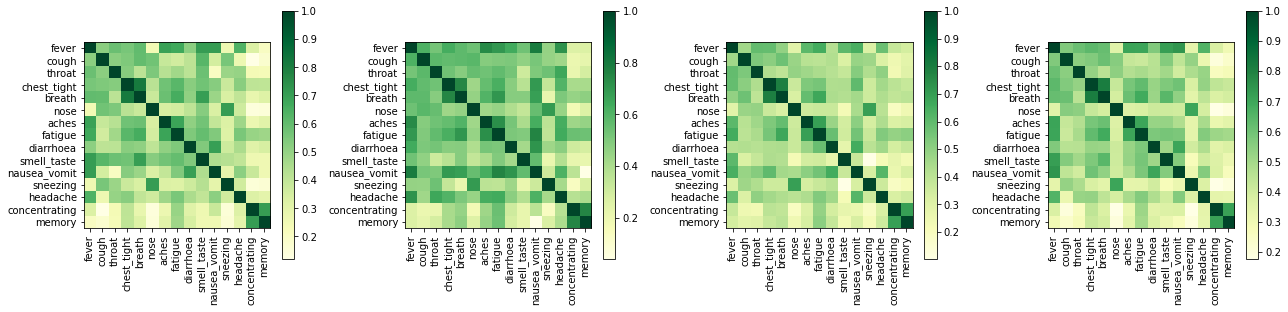

In [24]:
fig, ax_list = plt.subplots(1,4,figsize=(18,5))
plt.set_cmap('YlGn')
status_list = [0,1,2]
symptoms = core_symp
for status in status_list:
    
    ax = ax_list[status]
    
    df = dta2.loc[dta2.covid_status==status]
    
    corr_ = np.zeros((len(symptoms),len(symptoms)))

    for i,s1 in enumerate(symptoms):
        for j,s2 in enumerate(symptoms):
            corr_[i][j] = tetrachoric_corr(df[s1],df[s2])
    
    im = ax.imshow(corr_)
    
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    ax.set_xticks(np.arange(df[symptoms].shape[1]))
    ax.set_xticklabels(symptoms, rotation=90)
    
    ax.set_yticks(np.arange(df[symptoms].shape[1]))
    ax.set_yticklabels(symptoms)
    
    corr_df = pd.DataFrame(corr_, index=symptoms, columns=symptoms)
    
    corr_df.to_csv(f'llc_0028_symptomcorr_{status}_data_v2.csv')
    
ax = ax_list[-1]
df = dta2
status = 'all'
corr_ = np.zeros((len(symptoms),len(symptoms)))

for i,s1 in enumerate(symptoms):
    for j,s2 in enumerate(symptoms):
        corr_[i][j] = tetrachoric_corr(df[s1],df[s2])
    
im = ax.imshow(corr_)
    
plt.colorbar(im, ax=ax, shrink=0.8)
    
ax.set_xticks(np.arange(df[symptoms].shape[1]))
ax.set_xticklabels(symptoms, rotation=90)
    
ax.set_yticks(np.arange(df[symptoms].shape[1]))
ax.set_yticklabels(symptoms)
    
corr_df = pd.DataFrame(corr_, index=symptoms, columns=symptoms)
    
corr_df.to_csv(f'llc_0028_symptomcorr_{status}_data_v2.csv')
    
plt.tight_layout()
plt.show()